In [ ]:
### Paquetes y descarga de las bases

In [1]:
# Paquetes empleados

import os 
import pandas as pd # Manipulacion de datos
import numpy as np # Calculos numericos
import matplotlib.pyplot as plt # Graficos
import seaborn as sns # Grafico
import statsmodels.api as sm     
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, recall_score 
from sklearn.metrics import RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler # Estandarizacion de datos

In [3]:
# r"C:\Trabajos\Maestria\2 año\Tercer trimestre\Taller de programación\BigDataUBA-Grupo1\BigDataUBA-Grupo1\TP2\basei_unida.xlsx" # path de Fran 1
# r"C:\Repositorios\BigDataUBA-Grupo1\TP2\basei_unida.xlsx" # path de Fran 2
# r"C:\Users\juanc\Documents\GitHub\BigDataUBA-Grupo1\TP2\basei_unida.xlsx" ruta juan
# r"C:\Users\Usuario\Desktop\Maestria\Programacion\BigDataUBA-Grupo1\TP2\Bases\basei_unida.xlsx" ruta compu escritorio juan

base = pd.read_excel(r"C:\Users\juanc\Documents\GitHub\BigDataUBA-Grupo1\TP3\bases\respondieron_2025.xlsx")

In [ ]:
###Parte c: Vecinos cercanos

In [4]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4157 entries, 0 to 4156
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CODUSU                   4157 non-null   object 
 1   NRO_HOGAR                4157 non-null   int64  
 2   COMPONENTE               4157 non-null   int64  
 3   H15                      4157 non-null   int64  
 4   ANO4                     4157 non-null   int64  
 5   TRIMESTRE                4157 non-null   int64  
 6   REGION                   4157 non-null   int64  
 7   PONDERA                  4157 non-null   int64  
 8   CH03                     4157 non-null   int64  
 9   CH04                     4157 non-null   int64  
 10  CH06                     4157 non-null   int64  
 11  CH07                     4157 non-null   int64  
 12  CH08                     4157 non-null   int64  
 13  NIVEL_ED                 4157 non-null   int64  
 14  ESTADO                  

In [5]:
#Antes de separar en train y test elimino los faltantes de educ
base = base.dropna(subset=['educ'])

In [6]:
# Entrenaremos con el 70% de la base de datos y el resto se usarán para testear 
# el modelo obtenido

# 1. Definir features completas
features = [
    'educ',
    'CH06',
    'edad2',
    'horastrab',
    'CH04',
    'IX_TOT',
    'CH07',
    'CH08',
    'ESTADO'
]

X = base[features]
y = base['pobre']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=444)

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 0 to 4156
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   educ       4128 non-null   float64
 1   CH06       4128 non-null   int64  
 2   edad2      4128 non-null   int64  
 3   horastrab  4128 non-null   int64  
 4   CH04       4128 non-null   int64  
 5   IX_TOT     4128 non-null   int64  
 6   CH07       4128 non-null   int64  
 7   CH08       4128 non-null   int64  
 8   ESTADO     4128 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 322.5 KB


In [8]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) #vemos lo tamaños de cada subconjunto

(2889, 9) (1239, 9) (2889,) (1239,)


In [9]:
# Probar para distintos valores de K
for k in [1, 5, 10]:
    print(f'\n🔎 K = {k}')
    
    # 1. Definir el modelo
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # 2. Entrenar con el set de entrenamiento
    knn.fit(X_train, y_train)
    
    # 3. Predecir en el set de test
    y_pred = knn.predict(X_test)
    
    # 4. Evaluar el modelo
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Matriz de confusión:\n', confusion_matrix(y_test, y_pred))
    print('Reporte de clasificación:\n', classification_report(y_test, y_pred, target_names=['No pobre', 'Pobre']))


🔎 K = 1
Accuracy: 0.7425343018563357
Matriz de confusión:
 [[812 155]
 [164 108]]
Reporte de clasificación:
               precision    recall  f1-score   support

    No pobre       0.83      0.84      0.84       967
       Pobre       0.41      0.40      0.40       272

    accuracy                           0.74      1239
   macro avg       0.62      0.62      0.62      1239
weighted avg       0.74      0.74      0.74      1239


🔎 K = 5
Accuracy: 0.7917675544794189
Matriz de confusión:
 [[892  75]
 [183  89]]
Reporte de clasificación:
               precision    recall  f1-score   support

    No pobre       0.83      0.92      0.87       967
       Pobre       0.54      0.33      0.41       272

    accuracy                           0.79      1239
   macro avg       0.69      0.62      0.64      1239
weighted avg       0.77      0.79      0.77      1239


🔎 K = 10
Accuracy: 0.7958030669895076
Matriz de confusión:
 [[928  39]
 [214  58]]
Reporte de clasificación:
               p

In [10]:
#Preparo el grafico utilizando como variables años de educacion y horas trabajadas
X_train_viz = X_train[['educ', 'horastrab']].copy()
X_test_viz = X_test[['educ', 'horastrab']].copy()

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_viz)
X_test_scaled = scaler.transform(X_test_viz)


In [12]:
# K=1
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_scaled, y_train)

# K=10
knn10 = KNeighborsClassifier(n_neighbors=10)
knn10.fit(X_train_scaled, y_train)


KNeighborsClassifier(n_neighbors=10)

In [13]:
def plot_decision_boundary(model, X, y, title):
    h = 0.1  # paso de la grilla
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Crear una grilla de puntos
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predecir clase para cada punto de la grilla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Graficar frontera de decisión
    plt.contourf(xx, yy, Z, cmap=plt.cm.Pastel1, alpha=0.8)

    # Graficar puntos verdaderos
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k', s=20)
    plt.xlabel("Educación (estandarizada)")
    plt.ylabel("Horas trabajadas (estandarizadas)")
    plt.title(title)
    plt.legend(*scatter.legend_elements(), title="Pobre")
    plt.grid(False)

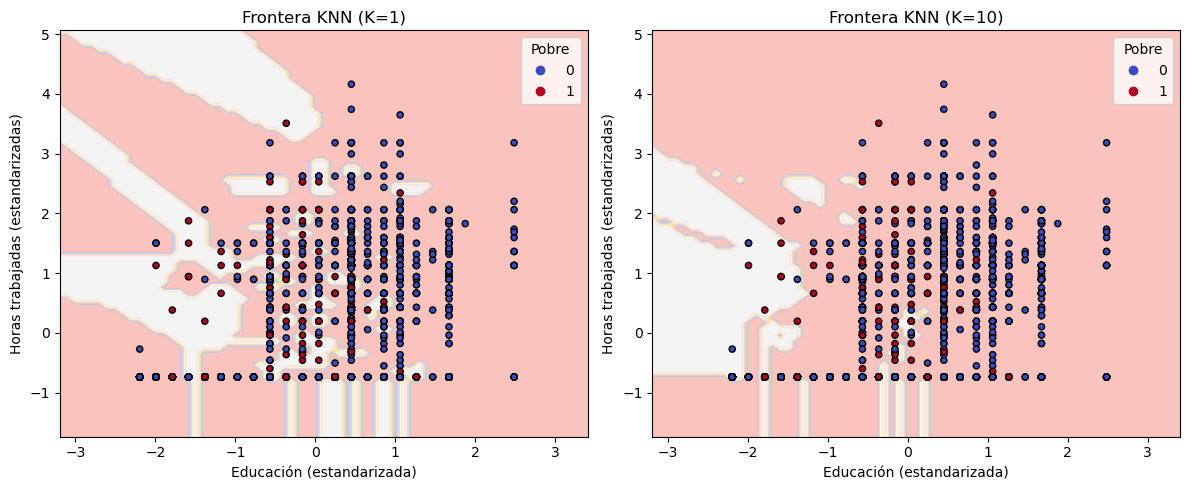

In [14]:
plt.figure(figsize=(12, 5))

# K=1
plt.subplot(1, 2, 1)
plot_decision_boundary(knn1, X_train_scaled, y_train, "Frontera KNN (K=1)")

# K=10
plt.subplot(1, 2, 2)
plot_decision_boundary(knn10, X_train_scaled, y_train, "Frontera KNN (K=10)")

plt.tight_layout()
plt.show()
